# Training Machine Learning With the produced segmanent windows from EDA Part.

In [1]:
import pandas as pd
import yaml
import pickle
from pathlib import Path
import numpy as np
import utils
import utils_visual
import os
from utils import model_names


# Step 1: Get the training and test sets from the output directory

In [2]:
cache_path = Path("outputs/cache/segmented.pkl")
with open(cache_path, "rb") as f:
    data = pickle.load(f)

train_mask = data["train_mask"]
test_mask = data["test_mask"]
Windows = data["windows"]
labels_arr = data["labels"]
groups = data["users"][data["train_mask"]]

BASE_DIR = Path(os.getcwd()).resolve()

with open(BASE_DIR / "config.yml", "r", encoding="utf-8") as file:
    cfg = yaml.safe_load(file)

# Step 2: More Data Preperation Before the ML Training.

In [3]:
#Scalling the test and training set mixed scaling is used in this model
train_set, test_set = utils.MixedScaling(train_mask, test_mask, Windows)
labels_train = labels_arr[train_mask]
labels_test = labels_arr[test_mask]

Έτοιμα Train δεδομένα με σχήμα: (3012, 1200)
Έτοιμα Test δεδομένα με σχήμα: (1494, 1200)


# Step 3: Model Training. In this section we are going to train 3 models SVM Gradient Boosting and Logic Regression

In [4]:
trained_models, predictions = utils.TrainAllMLs(train_set, labels_train, test_set, cfg)

/home/stamylaptop/PycharmProjects/MergeFeatureMLWindowing/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# Step 4: Evaluating models



 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: svm-rbf

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.11      0.28      0.16       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.00      0.00      0.00       299
 swipe-right       0.00      0.00      0.00       296
     texting       0.53      0.48      0.51       299

    accuracy                           0.15      1494
   macro avg       0.13      0.15      0.13      1494
weighted avg       0.13      0.15      0.13      1494

[2] Ανάλυση True/False Θετικών και Αρνητικών ανά Χειρονομία:
  • Χειρονομία 'scroll-down':
    - True Positives (TP) : 85  (Σωστή πρόβλεψη της κίνησης)
    - False Positives (FP): 669  (Άλλη κίνηση που μπερδεύτηκε ως 'scroll-down')
    - False Negatives (FN): 216  (Πραγματικό 'scroll-down' που χάθηκε)
    - True Negatives (TN) : 524  (Σωστή απόρριψη μη σχετικών κινήσεων)

  • Χειρονομία 'scroll-up':
    - True Positives (TP) : 0  (Σωστή πρόβλεψη 

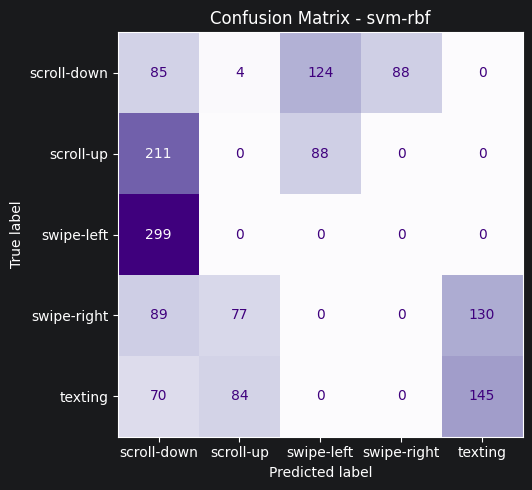


 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: randomforest

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.00      0.00      0.00       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.03      0.03      0.03       299
 swipe-right       0.26      0.48      0.34       296
     texting       0.70      0.90      0.79       299

    accuracy                           0.28      1494
   macro avg       0.20      0.28      0.23      1494
weighted avg       0.20      0.28      0.23      1494

[2] Ανάλυση True/False Θετικών και Αρνητικών ανά Χειρονομία:
  • Χειρονομία 'scroll-down':
    - True Positives (TP) : 0  (Σωστή πρόβλεψη της κίνησης)
    - False Positives (FP): 193  (Άλλη κίνηση που μπερδεύτηκε ως 'scroll-down')
    - False Negatives (FN): 301  (Πραγματικό 'scroll-down' που χάθηκε)
    - True Negatives (TN) : 1000  (Σωστή απόρριψη μη σχετικών κινήσεων)

  • Χειρονομία 'scroll-up':
    - True Positives (TP) : 0  (Σωστή πρόβ

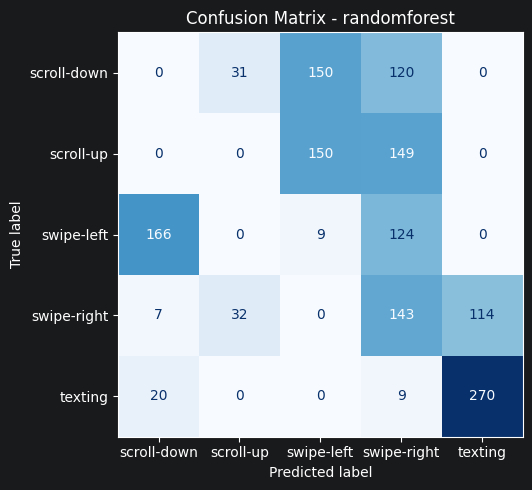


 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: gradient-boosting

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.00      0.00      0.00       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.03      0.03      0.03       299
 swipe-right       0.02      0.03      0.03       296
     texting       0.68      0.93      0.78       299

    accuracy                           0.20      1494
   macro avg       0.15      0.20      0.17      1494
weighted avg       0.15      0.20      0.17      1494

[2] Ανάλυση True/False Θετικών και Αρνητικών ανά Χειρονομία:
  • Χειρονομία 'scroll-down':
    - True Positives (TP) : 0  (Σωστή πρόβλεψη της κίνησης)
    - False Positives (FP): 349  (Άλλη κίνηση που μπερδεύτηκε ως 'scroll-down')
    - False Negatives (FN): 301  (Πραγματικό 'scroll-down' που χάθηκε)
    - True Negatives (TN) : 844  (Σωστή απόρριψη μη σχετικών κινήσεων)

  • Χειρονομία 'scroll-up':
    - True Positives (TP) : 0  (Σωστή 

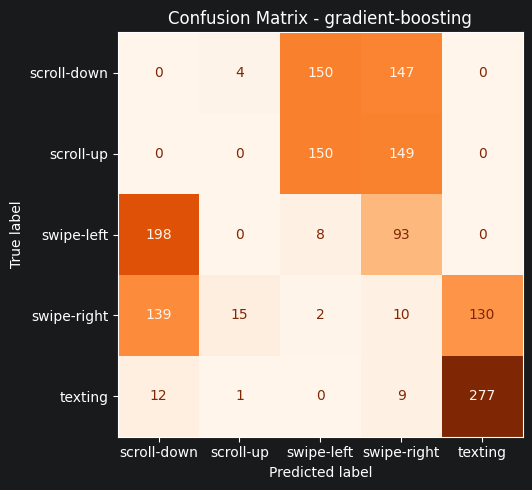


 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: logistic-regression

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.17      0.29      0.21       301
   scroll-up       0.09      0.09      0.09       299
  swipe-left       0.37      0.29      0.33       299
 swipe-right       0.15      0.18      0.16       296
     texting       0.71      0.25      0.37       299

    accuracy                           0.22      1494
   macro avg       0.30      0.22      0.23      1494
weighted avg       0.30      0.22      0.23      1494

[2] Ανάλυση True/False Θετικών και Αρνητικών ανά Χειρονομία:
  • Χειρονομία 'scroll-down':
    - True Positives (TP) : 86  (Σωστή πρόβλεψη της κίνησης)
    - False Positives (FP): 423  (Άλλη κίνηση που μπερδεύτηκε ως 'scroll-down')
    - False Negatives (FN): 215  (Πραγματικό 'scroll-down' που χάθηκε)
    - True Negatives (TN) : 770  (Σωστή απόρριψη μη σχετικών κινήσεων)

  • Χειρονομία 'scroll-up':
    - True Positives (TP) : 28  (Σω

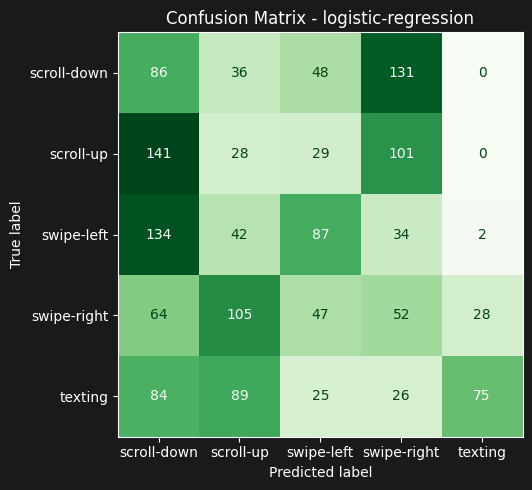

In [5]:
colormaps = ["Purples", "Blues", "Oranges", "Greens"]
for i in range(len(model_names)):
    # Run the visual evaluation function
    utils_visual.ModelEvaluation(
        model_name=model_names[i],
        test_labels=labels_test,
        y_pred=predictions[i],
        classes=trained_models[i].classes_,
        cmap=colormaps[i]
    )


# Fine Tunning.

Fitting 2 folds for each of 12 candidates, totalling 24 fits

 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: svm-rbf

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.12      0.29      0.16       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.00      0.00      0.00       299
 swipe-right       0.00      0.00      0.00       296
     texting       0.53      0.48      0.50       299

    accuracy                           0.15      1494
   macro avg       0.13      0.15      0.13      1494
weighted avg       0.13      0.15      0.13      1494

[2] Ανάλυση True/False Θετικών και Αρνητικών ανά Χειρονομία:
  • Χειρονομία 'scroll-down':
    - True Positives (TP) : 87  (Σωστή πρόβλεψη της κίνησης)
    - False Positives (FP): 669  (Άλλη κίνηση που μπερδεύτηκε ως 'scroll-down')
    - False Negatives (FN): 214  (Πραγματικό 'scroll-down' που χάθηκε)
    - True Negatives (TN) : 524  (Σωστή απόρριψη μη σχετικών κινήσεων)

  • Χειρονομία

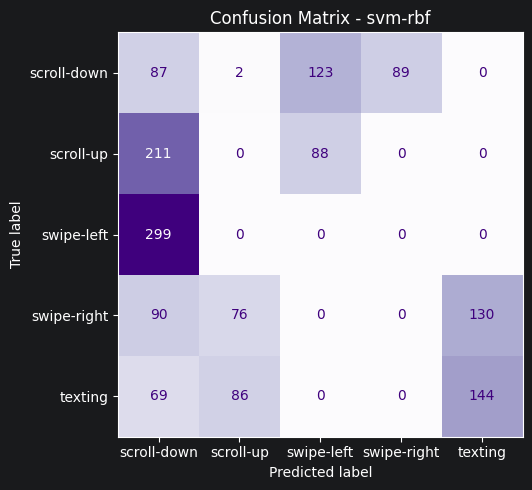

Fitting 2 folds for each of 12 candidates, totalling 24 fits

 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: randomforest

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.00      0.00      0.00       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.02      0.02      0.02       299
 swipe-right       0.26      0.48      0.33       296
     texting       0.71      0.89      0.79       299

    accuracy                           0.28      1494
   macro avg       0.20      0.28      0.23      1494
weighted avg       0.20      0.28      0.23      1494

[2] Ανάλυση True/False Θετικών και Αρνητικών ανά Χειρονομία:
  • Χειρονομία 'scroll-down':
    - True Positives (TP) : 0  (Σωστή πρόβλεψη της κίνησης)
    - False Positives (FP): 192  (Άλλη κίνηση που μπερδεύτηκε ως 'scroll-down')
    - False Negatives (FN): 301  (Πραγματικό 'scroll-down' που χάθηκε)
    - True Negatives (TN) : 1001  (Σωστή απόρριψη μη σχετικών κινήσεων)

  • Χειρο

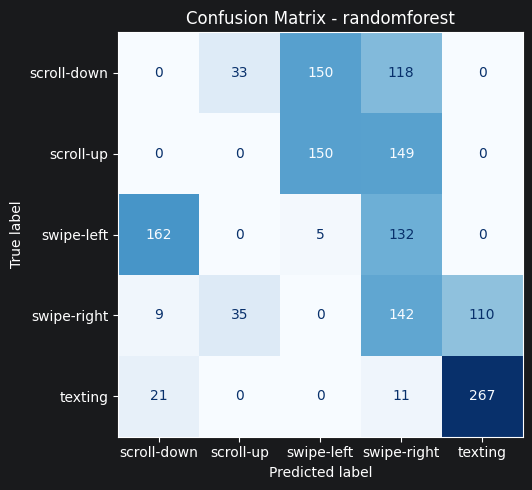

Fitting 2 folds for each of 18 candidates, totalling 36 fits

 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: gradient-boosting

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.00      0.00      0.00       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.03      0.03      0.03       299
 swipe-right       0.16      0.27      0.20       296
     texting       0.69      0.93      0.79       299

    accuracy                           0.24      1494
   macro avg       0.17      0.25      0.20      1494
weighted avg       0.17      0.24      0.20      1494

[2] Ανάλυση True/False Θετικών και Αρνητικών ανά Χειρονομία:
  • Χειρονομία 'scroll-down':
    - True Positives (TP) : 0  (Σωστή πρόβλεψη της κίνησης)
    - False Positives (FP): 260  (Άλλη κίνηση που μπερδεύτηκε ως 'scroll-down')
    - False Negatives (FN): 301  (Πραγματικό 'scroll-down' που χάθηκε)
    - True Negatives (TN) : 933  (Σωστή απόρριψη μη σχετικών κινήσεων)

  • Χ

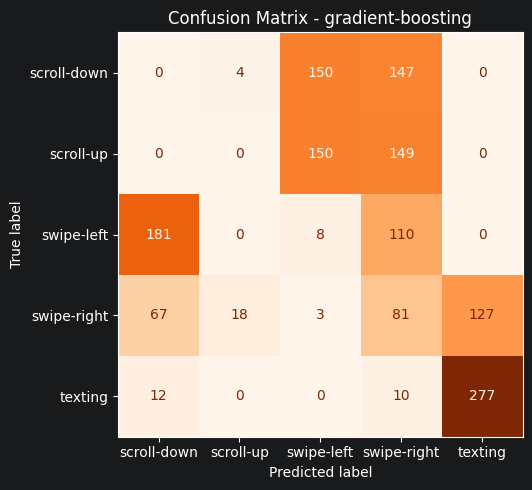

Fitting 2 folds for each of 8 candidates, totalling 16 fits


/home/stamylaptop/PycharmProjects/MergeFeatureMLWindowing/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/stamylaptop/PycharmProjects/MergeFeatureMLWindowing/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/stamylaptop/PycharmProjects/MergeFeatureMLWindowing/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not conver


 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: logistic-regression

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.18      0.29      0.22       301
   scroll-up       0.11      0.11      0.11       299
  swipe-left       0.36      0.32      0.34       299
 swipe-right       0.17      0.20      0.18       296
     texting       0.74      0.22      0.34       299

    accuracy                           0.23      1494
   macro avg       0.31      0.23      0.24      1494
weighted avg       0.31      0.23      0.24      1494

[2] Ανάλυση True/False Θετικών και Αρνητικών ανά Χειρονομία:
  • Χειρονομία 'scroll-down':
    - True Positives (TP) : 87  (Σωστή πρόβλεψη της κίνησης)
    - False Positives (FP): 406  (Άλλη κίνηση που μπερδεύτηκε ως 'scroll-down')
    - False Negatives (FN): 214  (Πραγματικό 'scroll-down' που χάθηκε)
    - True Negatives (TN) : 787  (Σωστή απόρριψη μη σχετικών κινήσεων)

  • Χειρονομία 'scroll-up':
    - True Positives (TP) : 32  (Σω

/home/stamylaptop/PycharmProjects/MergeFeatureMLWindowing/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


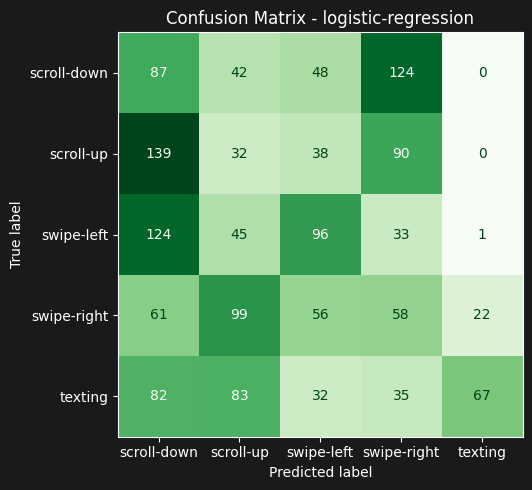

In [6]:

# 1. Fine-Tuning για το Gradient Boosting
n_features_raw = 6
n_timesteps = train_set.shape[1] // n_features_raw

flat_feature_names = []
for ts in range(n_timesteps):
    flat_feature_names.extend([
        f"acc_x_ts{ts}", f"acc_y_ts{ts}", f"acc_z_ts{ts}",
        f"gyr_x_ts{ts}", f"gyr_y_ts{ts}", f"gyr_z_ts{ts}"
    ])

# 3. Create your dataframes WITH these clean text string headers
train_set_df = pd.DataFrame(train_set, columns=flat_feature_names)
test_set_df = pd.DataFrame(test_set, columns=flat_feature_names)

for i in range(len(model_names)):
    best_pipeline, best_params, best_cv_score = utils.Fine_tuning(
        model_names[i],
        train_set_df,
        labels_train,
        groups,
        cfg
    )
    preds = best_pipeline.predict(test_set_df)
    utils_visual.ModelEvaluation(
        model_name=model_names[i],
        test_labels=labels_test,
        y_pred=preds,
        classes=best_pipeline.classes_,
        cmap=colormaps[i]
    )

